In [1]:
!apt-get update && apt-get install -y libgl1-mesa-glx
!pip install --upgrade pip

%cd /kaggle/working
!git clone https://github.com/kohya-ss/sd-scripts.git
%cd sd-scripts

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install --upgrade accelerate transformers diffusers library
!pip install -r requirements.txt
!pip install xformers==0.0.21  #P100/T4
!pip install dadaptation bitsandbytes 

from accelerate.utils import write_basic_config
write_basic_config()

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]               
Get:3 https://cli.github.com/packages stable/main amd64 Packages [354 B]       
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease   
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]          
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease   
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]    
Get:13 http

PosixPath('/root/.cache/huggingface/accelerate/default_config.yaml')

In [2]:
import os
import shutil

root_dir = "/kaggle/working/ucla_lora"
train_data_dir = os.path.join(root_dir, "train_data")
reg_data_dir = os.path.join(root_dir, "reg_data")
output_dir = os.path.join(root_dir, "output")
logging_dir = os.path.join(root_dir, "logs")

for d in [train_data_dir, reg_data_dir, output_dir, logging_dir]:
    os.makedirs(d, exist_ok=True)

subset_dir = os.path.join(train_data_dir, "20_uclastyle")
os.makedirs(subset_dir, exist_ok=True)

input_dataset_path = "/kaggle/input/datasets/gyx007/ucla-arch-dataset"
for img in os.listdir(input_dataset_path):
    if img.endswith(('.jpg', '.png', '.jpeg')):
        shutil.copy(os.path.join(input_dataset_path, img), subset_dir)

print(f"dataset is ready: {subset_dir}")

数据集已准备完毕，存放于: /kaggle/working/ucla_lora/train_data/20_uclastyle


In [3]:
!pip uninstall -y timm
!pip install timm==0.9.12 fairscale==0.4.13

%cd /kaggle/working/sd-scripts

import os

train_data_dir = "/kaggle/working/ucla_lora/train_data/20_uclastyle"
core_prompt = "uclastyle, architecture, university campus, red brick building, ornate windows, sunny day"

if os.path.exists(train_data_dir):
    files = os.listdir(train_data_dir)
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    
    print(f"正在为 {len(image_files)} 张 UCLA 建筑照片生成标签...")
    
    count = 0
    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        txt_path = os.path.join(train_data_dir, f"{base_name}.txt")
        
        with open(txt_path, 'w', encoding='utf-8') as f:
            f.write(core_prompt)
        count += 1
    
    print(f"Success！Generate {count} Tag file")
else:
    print(f"Error：Cannot find {train_data_dir} !")

Found existing installation: timm 1.0.25
Uninstalling timm-1.0.25:
  Successfully uninstalled timm-1.0.25
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 9.7 MB/s  0:00:00m eta 0:00:01
  Created wheel for fairscale: filename=fairscale-0.4.13-py3-none-any.whl size=332207 sha256=c0baabf6e83cf1e66e06c71bb5df46adc4a8088c60e0a753c712cef7321601f4
  Stored in directory: /root/.cache/pip/wheels/5a/88/aa/d84b2cf1bad6b273cbf661640141a82c7b9f496e024f80aac0
Successfully built fairscale
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [timm]1/2 [timm]
/kaggle/working/sd-scripts
正在为 52 张 UCLA 建筑照片生成标签...
✅ 成功！已生成 52 个标签文件。
示例文件: 043.jpg -> 043.txt


In [4]:
import os

%cd /kaggle/working/sd-scripts
!pip install bitsandbytes --quiet

!accelerate launch --num_cpu_threads_per_process=8 sdxl_train_network.py \
    --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0" \
    --train_data_dir="/kaggle/working/ucla_lora/train_data" \
    --output_dir="/kaggle/working/ucla_lora/output" \
    --logging_dir="/kaggle/working/ucla_lora/logs" \
    --resolution="768,768" \
    --network_module=networks.lora \
    --max_train_epochs=5 \
    --save_every_n_epochs=1 \
    --learning_rate=1e-4 \
    --unet_lr=1e-4 \
    --text_encoder_lr=5e-5 \
    --network_dim=128 \
    --network_alpha=64 \
    --train_batch_size=1 \
    --mixed_precision="fp16" \
    --save_precision="fp16" \
    --optimizer_type="AdamW8bit" \
    --cache_latents \
    --enable_bucket \
    --output_name="ucla_fast_v1" \
    --caption_extension=".txt" \
    --sdpa \
    --mem_eff_attn \
    --gradient_checkpointing \
    --gradient_accumulation_steps=1 \
    --lowram \
    --max_data_loader_n_workers=2

/kaggle/working/sd-scripts
2026-04-07 06:44:28.319297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-07 06:44:28.319297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775544268.510074     959 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775544268.510088     960 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775544268.565164     960 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1775544268.56

2026-04-07 11:38:43.524142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775561923.652587      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775561923.697970      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775561924.048400      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775561924.048435      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775561924.048437      55 computation_placer.cc:177] computation placer alr

config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

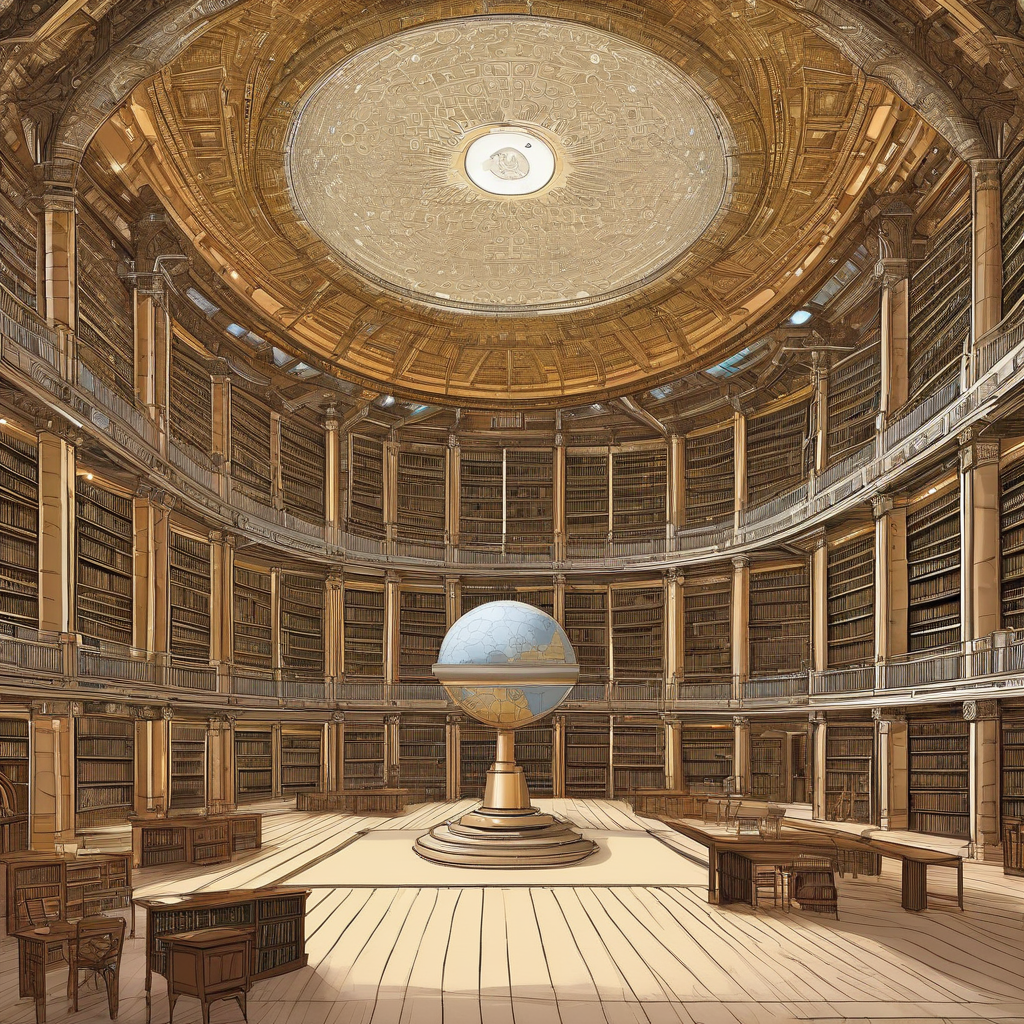

In [5]:
import torch
from diffusers import StableDiffusionXLPipeline, AutoencoderKL
from IPython.display import display

base_model_path = "stabilityai/stable-diffusion-xl-base-1.0"
lora_model_path = "/kaggle/working/ucla_lora/output/ucla_fast_v1.safetensors" 

vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
pipe = StableDiffusionXLPipeline.from_pretrained(
    base_model_path, 
    vae=vae,
    torch_dtype=torch.float16, 
    variant="fp16",
    use_safetensors=True
)
pipe.to("cuda")
pipe.load_lora_weights(lora_model_path, adapter_name="ucla")

# prompt = "uclastyle, a cinematic shot of a grand library with red brick walls, sunset lighting, highly detailed architecture, 8k"
# prompt = "uclastyle, interior of a historic university building, high vaulted ceilings, grand staircase, sunlight streaming through arched windows, red brick interior walls, scholarly atmosphere, cinematic shadows, masterpiece."
# prompt = "uclastyle, a modern data science center, fusion of red brick tradition and glass curtain walls, futuristic architectural design, tech campus, sunset reflection on glass, high-tech interior visible, crisp details."
# prompt = "uclastyle, a modern data science center"
# prompt = "uclastyle, a cinematic shot of a grand library with red brick walls, sunset lighting, highly detailed architecture, 8k"
prompt = "uclastyle, a grand library in deep space"
negative_prompt = "broken windows, messy, blurry, low quality, distorted, people"

image = pipe(
    prompt=prompt, 
    negative_prompt=negative_prompt, 
    num_inference_steps=30, 
    guidance_scale=7.5,
    cross_attention_kwargs={"scale": 0.9} 
).images[0]

image.save("/kaggle/working/ucla_lora/output/ucla_test_result.png")
display(image)